# 03 · Exploratory Data Analysis (EDA)

Goal: understand the cleaned full-catalog data (`data/item_clean_full.csv`)
before choosing and tuning models: distributions, outliers, relationships
with price, districts, correlations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()  # nicer default look for all plots below

## 1. Overview

Size of the dataset, column types, missing values.

In [2]:
df = pd.read_csv("../data/item_clean_full.csv")
df.shape

(9541, 13)

In [3]:
df.head()

,id,price,currency,rooms,area,floor,floors,hasRepair,isVipped,isFeatured,location,city,price_per_m2
0,6176591,310000,AZN,2,81.0,3,17,True,False,False,Gənclik,Bakı,3827.16
1,5897242,310000,AZN,3,119.0,2,15,True,False,False,Neftçilər,Bakı,2605.04
2,6480127,339000,AZN,3,85.0,5,20,True,True,False,Şah İsmayıl Xətai,Bakı,3988.24
3,6398388,690000,AZN,4,210.0,3,14,True,True,False,İçəri Şəhər,Bakı,3285.71
4,6417622,270000,AZN,3,77.0,4,17,True,False,False,İnşaatçılar,Bakı,3506.49


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9541 entries, 0 to 9540
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            9541 non-null   int64  
 1   price         9541 non-null   int64  
 2   currency      9541 non-null   str    
 3   rooms         9541 non-null   int64  
 4   area          9541 non-null   float64
 5   floor         9541 non-null   int64  
 6   floors        9541 non-null   int64  
 7   hasRepair     9527 non-null   object 
 8   isVipped      9541 non-null   bool   
 9   isFeatured    9541 non-null   bool   
 10  location      9541 non-null   str    
 11  city          9541 non-null   str    
 12  price_per_m2  9541 non-null   float64
dtypes: bool(2), float64(2), int64(5), object(1), str(3)
memory usage: 838.7+ KB


**Findings:** 9541 listings, 13 columns. Only `hasRepair` has missing
values (14 rows); that is also why its dtype is `object` instead of
`bool` — a boolean column cannot hold missing values in pandas.

## 2. Target: price

How prices are distributed and whether there are extreme values.

In [5]:
df["price"].describe()

count    9.541000e+03
mean     2.956533e+05
std      2.047890e+05
min      2.300000e+04
25%      1.740000e+05
50%      2.400000e+05
75%      3.500000e+05
max      4.020000e+06
Name: price, dtype: float64

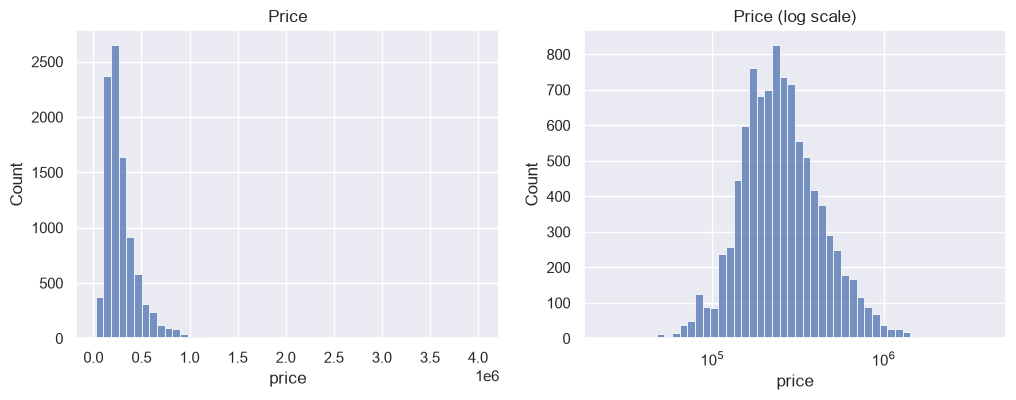

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["price"], bins=50, ax=axes[0])
axes[0].set_title("Price")

sns.histplot(df["price"], bins=50, log_scale=True, ax=axes[1])
axes[1].set_title("Price (log scale)")

plt.show()

**Findings:** Price is strongly right-skewed: half of listings cost
174k–350k AZN (IQR), with a long tail up to ~4M. On a log scale the
distribution is close to bell-shaped (log-normal). Hypothesis for step 04:
training on log(price) may help, since the model would then optimize
relative (percentage) errors instead of being dominated by rare expensive
listings. Small bump near ~100k: possibly a separate cheap segment, check
in the district section.

## 3. Numeric features

Distributions of rooms, area, floor and total floors.

In [7]:
numeric_cols = ["rooms", "area", "floor", "floors"]
df[numeric_cols].describe()

,rooms,area,floor,floors
count,9541.000000,9541.000000,9541.000000,9541.000000
mean,2.730531,98.260706,7.408238,12.892883
std,0.896896,56.145232,4.725560,5.417269
min,1.000000,15.000000,1.000000,1.000000
25%,2.000000,64.000000,4.000000,9.000000
50%,3.000000,85.000000,6.000000,15.000000
75%,3.000000,120.000000,11.000000,17.000000
max,19.000000,1000.000000,28.000000,33.000000


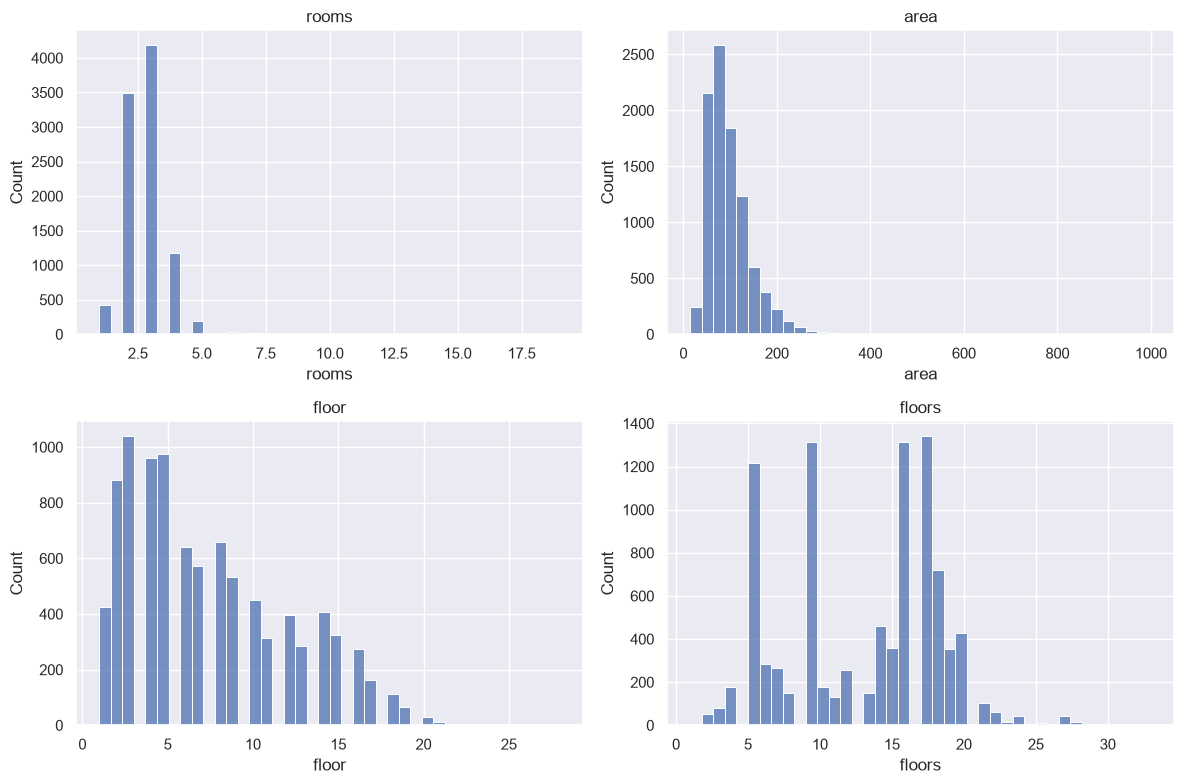

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], bins=40, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### Suspicious listings

Listings with 7+ rooms or 400+ m²: real large properties or data errors?

In [9]:
suspicious = df[(df["rooms"] >= 7) | (df["area"] >= 400)]
print(len(suspicious))
suspicious.sort_values("area", ascending=False)[["rooms", "area", "floor", "floors", "price", "price_per_m2", "location"]]

37


,rooms,area,floor,floors,price,price_per_m2,location
251,10,1000.0,20,21,1300000,1300.00,Şah İsmayıl Xətai
326,19,1000.0,20,21,1300000,1300.00,Şah İsmayıl Xətai
1054,10,1000.0,20,22,1300000,1300.00,Şah İsmayıl Xətai
5955,10,1000.0,15,16,1500000,1500.00,28 May
1138,10,1000.0,20,21,1300000,1300.00,Şah İsmayıl Xətai
7918,8,890.0,14,15,3200000,3595.51,Nizami
852,7,800.0,17,17,700000,875.00,Elmlər Akademiyası
9530,8,800.0,17,18,700000,875.00,Elmlər Akademiyası
4679,7,800.0,17,17,700000,875.00,Elmlər Akademiyası
3938,12,772.0,14,20,4020000,5207.25,Şah İsmayıl Xətai


### Duplicate listings

The same property seems to be listed several times under different ids.
If copies end up in both train and test, the test score is too optimistic
(a form of data leakage).

In [10]:
feature_cols = ["price", "rooms", "area", "floor", "floors", "location", "hasRepair"]

print(df.duplicated(subset=feature_cols).sum())

925


In [11]:
print(df["id"].duplicated().sum())

0


**Findings:**
- `rooms`: mostly 2–3 rooms; a few listings with 7–19 rooms.
- `area`: same right-skewed shape as price, most listings 50–150 m²,
  tail up to 1000 m².
- `floor`: gradually decreasing — low floors exist in every building,
  high floors only in tall ones.
- `floors`: clear peaks at 5, 9, 16–17 floors = typical building types
  (older Soviet-era 5/9-storey vs newer high-rises). Possible future
  feature: building type / age derived from `floors`.
- Large listings (7+ rooms or 400+ m²) are mostly high floors in tall
  buildings (whole floors / penthouses), not private houses. Some look
  like data errors (e.g. 10 vs 19 rooms for the same property).
- **925 duplicate listings (~10%)**: identical price, area, floor, floors,
  district and repair, but different `id`. No repeated `id`, so these are
  sellers re-posting the same property, not a scraper bug.
  Risk: copies in both train and test make the test score too optimistic
  (data leakage). Plan for step 04: drop duplicates before the
  train/test split and compare MAE.

## 4. Relationships with price

Starting with area, the feature most likely to drive price.

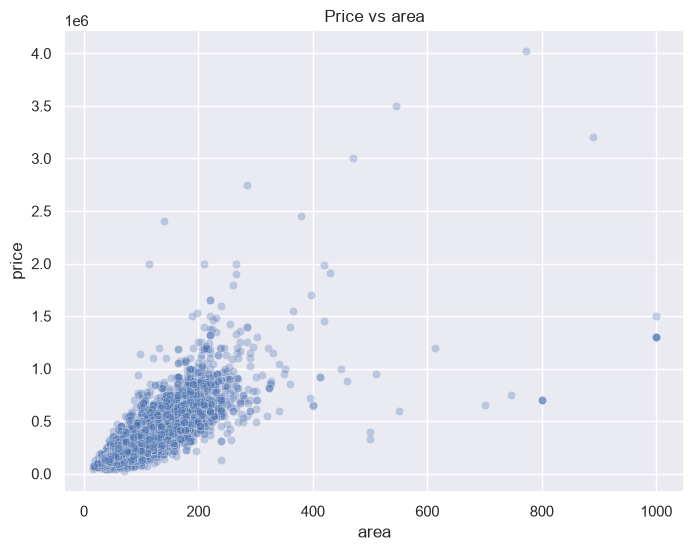

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(data=df, x="area", y="price", alpha=0.3, ax=ax)
ax.set_title("Price vs area")

plt.show()

**Findings:** Strong positive relationship: larger area → higher price.
The cloud widens as area grows (price spread increases with size), so
absolute errors will naturally be larger for big apartments — another
reason to test log(price) and look at MAPE in step 04. Points far above
the cloud are expensive for their size (likely location-driven); points
at 500–1000 m² with low prices are the suspicious "whole floor" listings.
Darker dots at 800 m² and 1000 m² are overlapping duplicates.

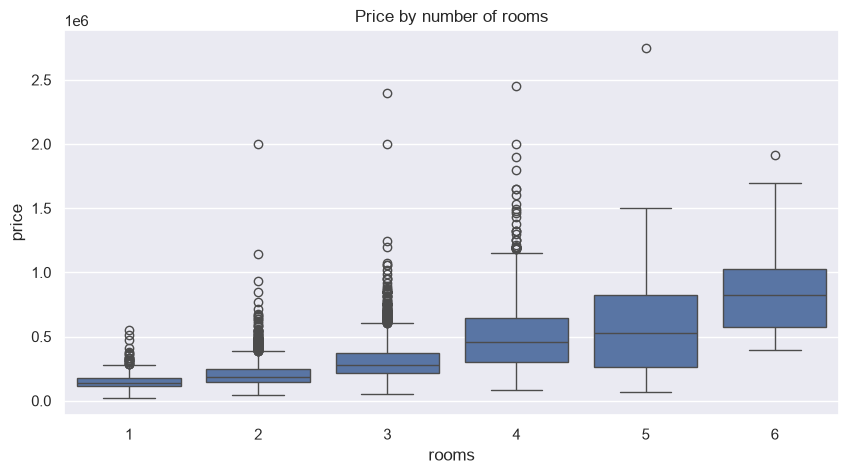

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df[df["rooms"] <= 6], x="rooms", y="price", ax=ax)
ax.set_title("Price by number of rooms")

plt.show()

**Findings:** Median price rises with the number of rooms (~150k for 1
room to ~820k for 6), and the spread grows too. Boxes overlap a lot:
many 4-room apartments cost less than a typical 3-room one, so rooms
alone do not determine price. Rooms are strongly tied to area, so they
may add little on top of it — to check in feature importance.

In [14]:
df.groupby("hasRepair")[["price", "area", "price_per_m2"]].median()

,price,area,price_per_m2
hasRepair,,,
False,318000.0,115.0,2887.32
True,235000.0,83.0,2868.20


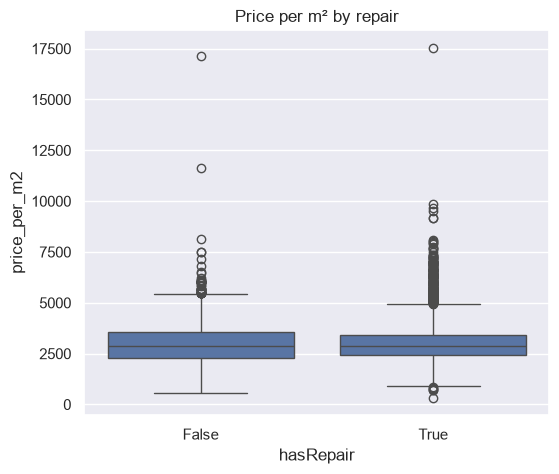

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(data=df, x="hasRepair", y="price_per_m2", ax=ax)
ax.set_title("Price per m² by repair")

plt.show()

In [16]:
tall = df["floors"] >= 12
pd.crosstab(tall, df["hasRepair"], normalize="index")

hasRepair,False,True
floors,,
False,0.084957,0.915043
True,0.185277,0.814723


In [17]:
df.groupby([tall, "hasRepair"])["price_per_m2"].median()

floors  hasRepair
False   False        3260.000
        True         2721.405
True    False        2819.715
        True         3000.000
Name: price_per_m2, dtype: float64

In [18]:
df.groupby([tall, "hasRepair"])["price_per_m2"].agg(["median", "count"])

median  count
floors hasRepair                 
False  False      3260.000    327
       True       2721.405   3522
True   False      2819.715   1052
       True       3000.000   4626

In [19]:
low_no_repair = df[(~tall) & (df["hasRepair"] == False)]
low_no_repair["location"].value_counts().head(10)

location
Ağ şəhər             91
Sea Breeze           48
Nardaran             41
Masazır              31
Nəriman Nərimanov    10
Nəsimi                7
Binəqədi              6
Şıxov                 5
Bakıxanov             5
Avtovağzal            5
Name: count, dtype: int64

**Findings (repair):** Overall, price per m² is almost the same with and
without repair (~2,900 AZN). Split by building height:
- tall buildings (12+ floors): with repair ~3,000 vs without ~2,820 —
  repair adds ~6%, as expected;
- lower buildings: without repair ~3,260 vs with ~2,721 — reversed.

The "low buildings without repair" group (327 listings) is dominated by
new premium developments: Ağ şəhər (91) and Sea Breeze (48), plus
Nardaran and Masazır. So "no repair" here mostly means "new building
sold without finishing", not "bad condition". The effect of repair is
confounded with building age / new-build status, which the data does not
contain, and building height is a poor proxy for it. This explains the
odd test where repair lowered the predicted price.

Possible improvement: scrape bina.az's new-build vs. resale flag
("Yeni tikili" / "Köhnə tikili") as an extra feature.

## 5. Districts

How strongly price per m² depends on location. Districts with fewer than
5 listings are excluded: a median from 1–2 listings is not reliable
(same threshold as the "Other" grouping in the model).

In [20]:
district_stats = (
    df.groupby("location")["price_per_m2"]
    .agg(["median", "count"])
    .sort_values("median", ascending=False)
)
district_stats = district_stats[district_stats["count"] >= 5]

print(len(district_stats))
district_stats.head(10)

59


,median,count
location,,
Ağ şəhər,5099.170,255
Bakmil,4142.860,25
Nardaran,4080.000,105
Sea Breeze,4057.970,139
Sahil,3977.780,91
İçəri Şəhər,3793.705,86
Mərdəkan,3585.080,10
Şah İsmayıl Xətai,3454.550,429
28 May,3448.280,431


In [21]:
district_stats.tail(10)

,median,count
location,,
Suraxanı,2039.025,20
M.Ə.Rəsulzadə,2000.000,7
Hövsan,1835.110,65
Abşeron,1732.775,124
Buzovna,1654.385,6
Məmmədli,1612.900,14
Binə,1571.430,5
Lökbatan,1517.125,32
Saray,1508.850,12


**Findings:** 59 districts have 5+ listings (matches the 59 categories +
"Other" used by the model). Median price per m² ranges from ~1,508 AZN
(Masazır) to ~5,099 AZN (Ağ şəhər), about 3.4×: the same 80 m² apartment
would cost ~121k vs ~408k. Top: new premium developments (Ağ şəhər,
Sea Breeze, Nardaran) and the city centre (Sahil, İçəri Şəhər, Nizami,
28 May, Xətai). Bottom: Absheron suburbs (Masazır, Saray, Lökbatan, ...).
Masazır is both the cheapest and one of the largest districts (282
listings) — likely the cheap bump near ~100k in the price histogram.
Bakmil ranks 2nd with only 25 listings: possibly a single new complex,
worth a closer look.
Location is one of the strongest price drivers. Note for feature
importance: it is split into 60 one-hot columns, so their importances
must be summed to compare location fairly with area.

## 6. Correlations

Pairwise correlation between numeric features (−1 to +1). Only captures
linear relationships between numeric columns, so location is not
included here even though it is a major price driver.

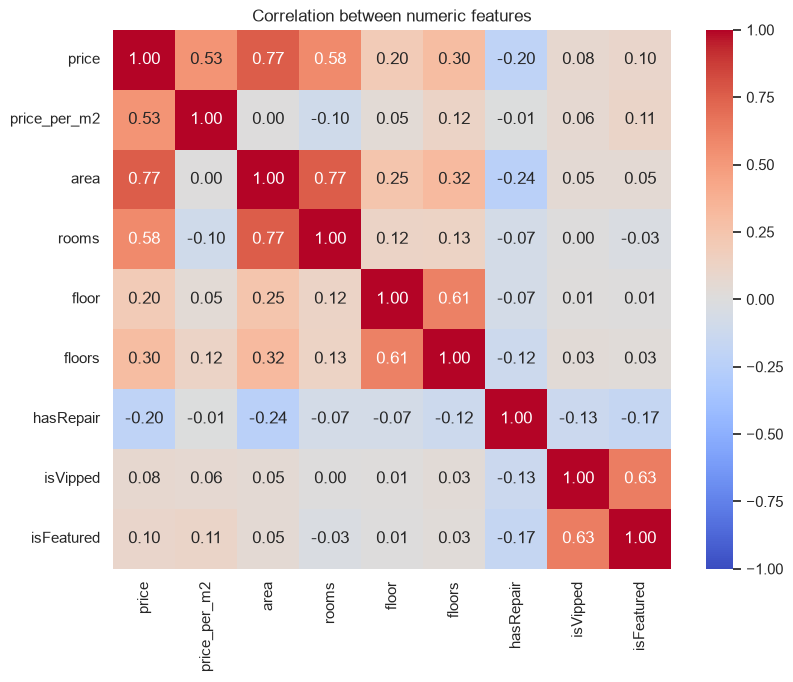

In [22]:
corr_cols = ["price", "price_per_m2", "area", "rooms", "floor",
             "floors", "hasRepair", "isVipped", "isFeatured"]

corr = df[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation between numeric features")

plt.show()

**Findings:**
- Area has the strongest correlation with price (0.77); rooms 0.58,
  floors 0.30, floor 0.20. isVipped / isFeatured are almost unrelated
  to price (0.08 / 0.10). price_per_m2 is derived from price, so it is
  excluded as a feature (leakage).
- Area and rooms are strongly correlated (0.77): rooms likely add little
  on top of area — to verify with feature importance.
- floor–floors 0.61 (high floors only exist in tall buildings);
  isVipped–isFeatured 0.63 (promotion flags bought together).
- hasRepair is negatively correlated with price (−0.20) and area (−0.24):
  large new-build apartments are often sold without repair, consistent
  with the repair section.
- Price per m² vs area: 0.00. Area drives total price, but price per m²
  is driven by something else — mainly location (section 5), which this
  map cannot show.

## 7. Summary and next steps

**Key findings**
1. Price is right-skewed with a long tail of expensive listings
   (log-normal shape).
2. Area (0.77 correlation) and location (3.4× difference in median price
   per m² between districts) are the main price drivers.
3. Rooms are largely redundant with area (0.77 correlation).
4. ~10% of listings (925) are duplicates re-posted by sellers.
5. "No repair" mostly means "new building sold without finishing"; the
   effect of repair is confounded with building age, which is not in the
   data.

**Next steps (04_model_selection)**
- Drop duplicates before the train/test split and re-measure MAE: the
  current score is likely too optimistic.
- Test training on log(price) and report MAPE alongside MAE.
- Compare many models (LazyPredict), then tune the best one (Optuna).

**Later ideas**
- Scrape the new-build / resale flag from bina.az.
- Check Bakmil (2nd most expensive district with only 25 listings).